## Chan-Vese Segmentation

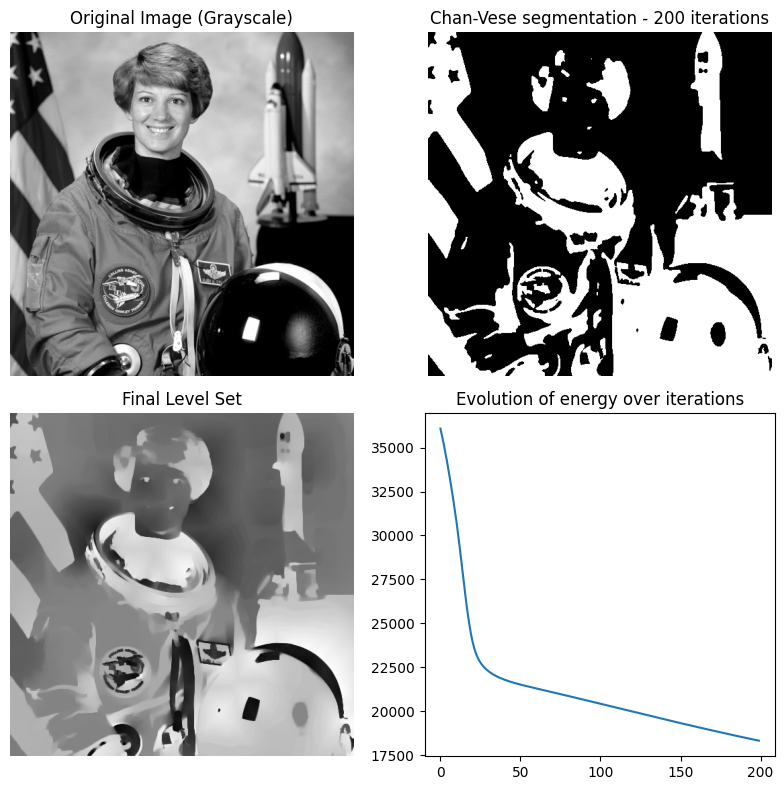

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color
from skimage.segmentation import chan_vese # the `skimage.segmentation.chan_vese()` function is used to segment objects using the Chan-Vese Algorithm, which is useful for segmenting objects without well-defined boundaries.

# load and convert the image to grayscale
image = img_as_float(data.astronaut())  # load the astronaut image
gray_image = color.rgb2gray(image)  # convert to grayscale for segmentation

# applying Chan-Vese segmentation
cv = chan_vese(
    gray_image,  # input image to be segmented
    mu=0.15,  # regularization parameter (higher value --> smoother boundaries)
    lambda1=1,  # weight for fitting the object region
    lambda2=1,  # weight for fitting the background region
    tol=1e-3,  # convergence tolerance (stops when energy change is small)
    max_num_iter=200,  # maximum number of iterations
    dt=0.5,  # time step for contour evolution
    init_level_set="checkerboard",  # initial contour shape
    extended_output=True,  # return extra output (energy evolution)
)

# plot results
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # create 2x2 subplot layout
ax = axes.flatten()  # flatten axes array for easier indexing

# show original grayscale image
ax[0].imshow(gray_image, cmap="gray")
ax[0].set_axis_off()
ax[0].set_title("Original Image (Grayscale)", fontsize=12)

# show segmented image
ax[1].imshow(cv[0], cmap="gray")
ax[1].set_axis_off()
title = f'Chan-Vese segmentation - {len(cv[2])} iterations'
ax[1].set_title(title, fontsize=12)

# show final level set (contour evolution result)
ax[2].imshow(cv[1], cmap="gray")
ax[2].set_axis_off()
ax[2].set_title("Final Level Set", fontsize=12)

# plot energy evolution over iterations
ax[3].plot(cv[2])
ax[3].set_title("Evolution of energy over iterations", fontsize=12)

# adjust layout to prevent overlapping elements
fig.tight_layout()

# display the results
plt.show()

## SLIC (Simple Linear Iterative Clustering)

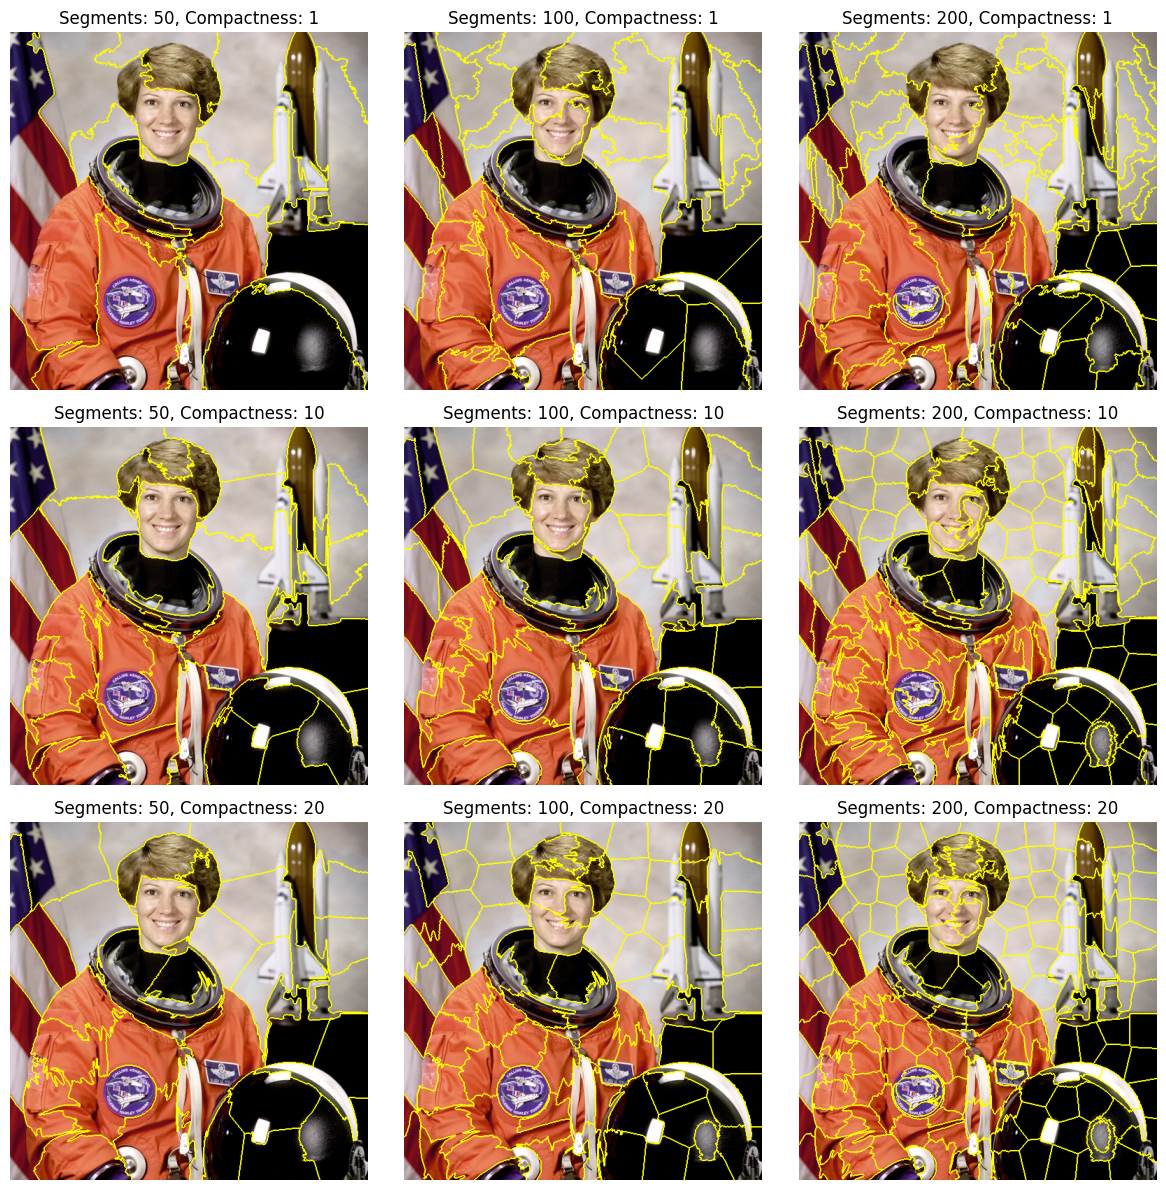

In [ ]:
from skimage.segmentation import slic, mark_boundaries
from skimage.data import astronaut
import matplotlib.pyplot as plt

"""
# skimage.segmentation.mark_boundaries()

The `mark_boundaries()` function is used to visualize segment boundaries in an image.

## Syntax
    skimage.segmentation.mark_boundaries(image, label_img)

## Parameters
- image : (ndarray) — Input image on which boundaries will be drawn.
- label_img : (ndarray) — Label array marking different segmented regions.
- color : (tuple, optional) — RGB color for segment boundaries (default: red).
- outline_color : (tuple, optional) — RGB color for the surrounding boundary.

## Return Value
- `marked`: (ndarray) — The image with the segment boundaries drawn.

"""

# Load sample image
image = astronaut()

# Define multiple parameter variations for segmentation
params = [
    (50, 1), (100, 1), (200, 1),   # Low compactness, increasing segments
    (50, 10), (100, 10), (200, 10), # Medium compactness, increasing segments
    (50, 20), (100, 20), (200, 20)  # High compactness, increasing segments
]

# Set up the figure
plt.figure(figsize=(12, 12))

for i, (n_segments, compactness) in enumerate(params, 1):
    # Apply SLIC segmentation
    segments = slic(image, n_segments=n_segments, compactness=compactness)

    # Plot the segmented image with boundaries
    plt.subplot(3, 3, i)
    plt.imshow(mark_boundaries(image, segments))
    plt.title(f"Segments: {n_segments}, Compactness: {compactness}")
    plt.axis("off")

# Show all plots
plt.tight_layout()
plt.show()


## Felzenszwalb’s Segmentation

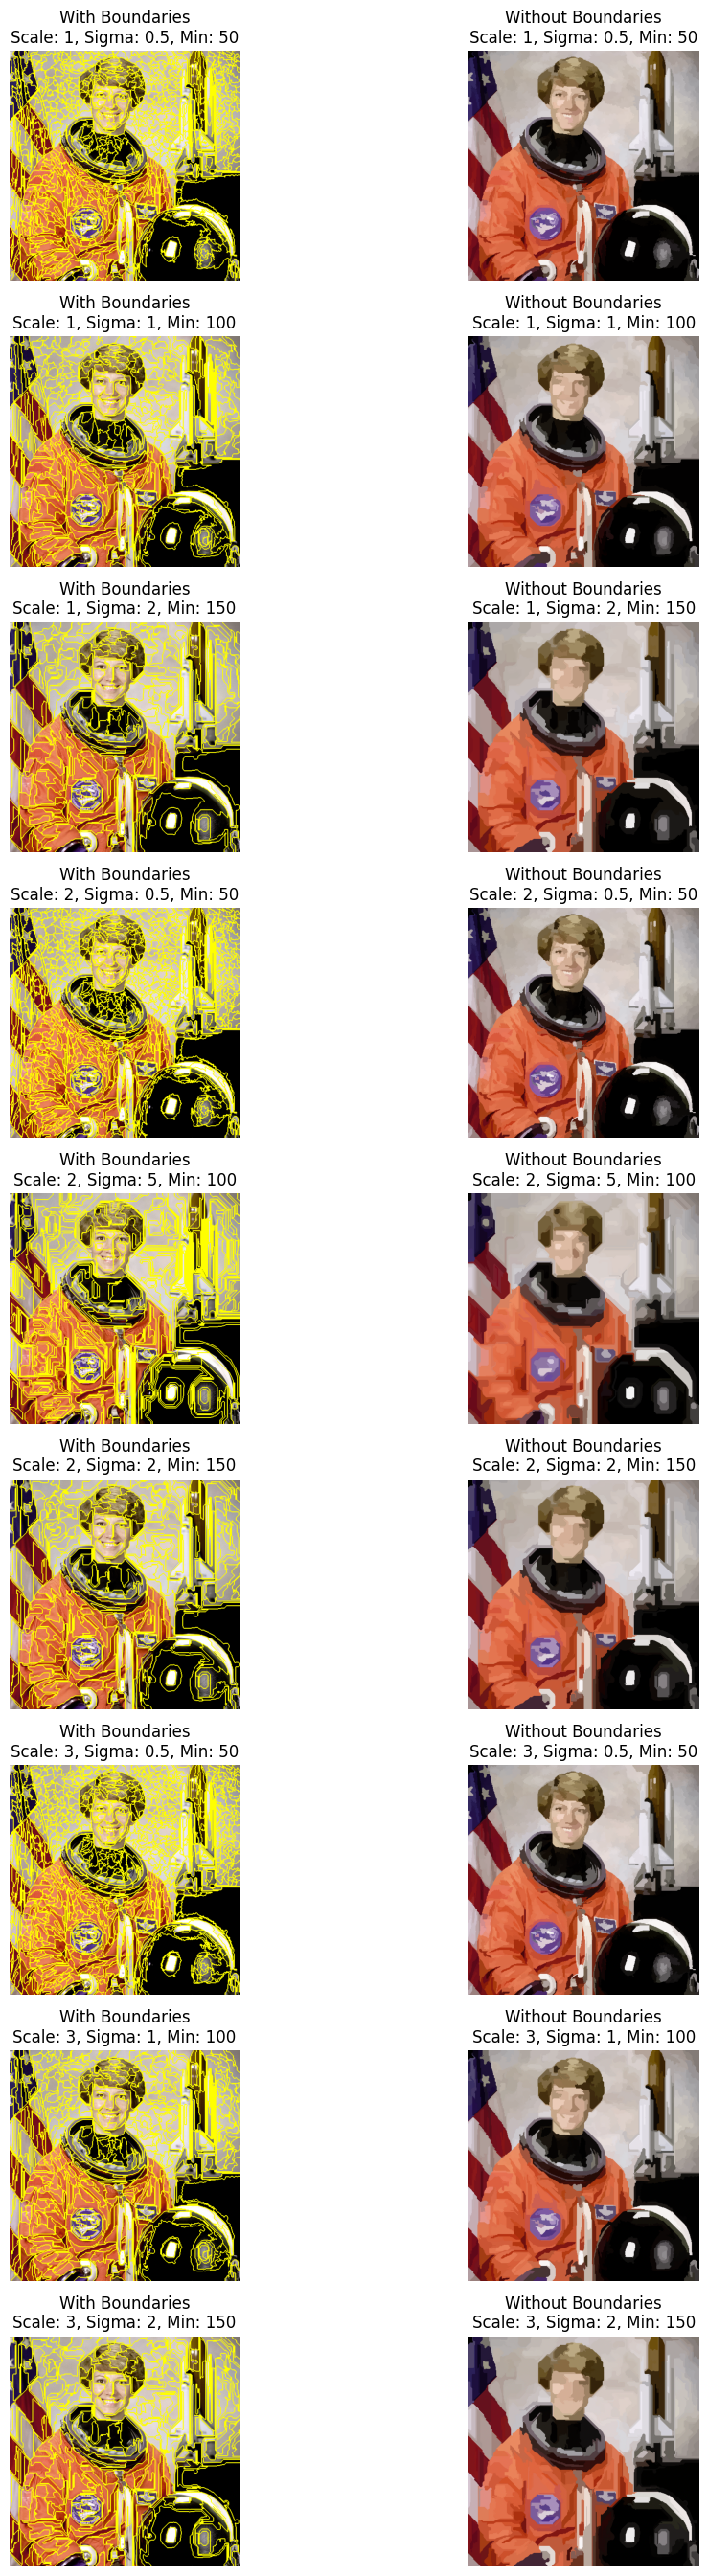

In [ ]:
# Importing required libraries
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb, mark_boundaries
from skimage.color import label2rgb
from skimage.data import astronaut

"""
# Felzenszwalb’s Segmentation in skimage

The `felzenszwalb()` function performs graph-based segmentation of an image using Felzenszwalb’s algorithm.

## Syntax
    skimage.segmentation.felzenszwalb(image, scale=1, sigma=0.8, min_size=20)

## Parameters
- `image` : (ndarray) — Input image to be segmented.
- `scale` : (float, optional) — Higher values lead to larger clusters.
- `sigma` : (float, optional) — Standard deviation for Gaussian blur pre-processing.
- `min_size` : (int, optional) — Minimum component size.

## Return Value
- `segments` : (ndarray) — Label matrix of the same shape as the input image, where each segment has a unique ID.
"""


# Importing required libraries
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb, mark_boundaries
from skimage.color import label2rgb
from skimage.data import astronaut

# Load sample image
image = astronaut()

# Define multiple parameter variations for segmentation
params = [
    (1, 0.5, 50), (1, 1, 100), (1, 2, 150),    # Scale = 1, Varying sigma and min_size
    (2, 0.5, 50), (2, 5, 100), (2, 2, 150),    # Scale = 2, Varying sigma and min_size
    (3, 0.5, 50), (3, 1, 100), (3, 2, 150)     # Scale = 3, Varying sigma and min_size
]

# Set up the figure (2 columns: with and without boundaries)
fig, axes = plt.subplots(len(params), 2, figsize=(12, len(params) * 3))

for i, (scale, sigma, min_size) in enumerate(params):
    # Apply Felzenszwalb segmentation
    segments = felzenszwalb(image, scale=scale, sigma=sigma, min_size=min_size)

    # Plot segmented image with boundaries
    axes[i, 0].imshow(mark_boundaries(image, segments))
    axes[i, 0].set_title(f"With Boundaries\nScale: {scale}, Sigma: {sigma}, Min: {min_size}")
    axes[i, 0].axis("off")

    # Plot segmented image without boundaries
    axes[i, 1].imshow(label2rgb(segments, image, kind='avg'))
    axes[i, 1].set_title(f"Without Boundaries\nScale: {scale}, Sigma: {sigma}, Min: {min_size}")
    axes[i, 1].axis("off")

# Adjust layout and show plots
plt.tight_layout()
plt.show()



## K-Means Clustering

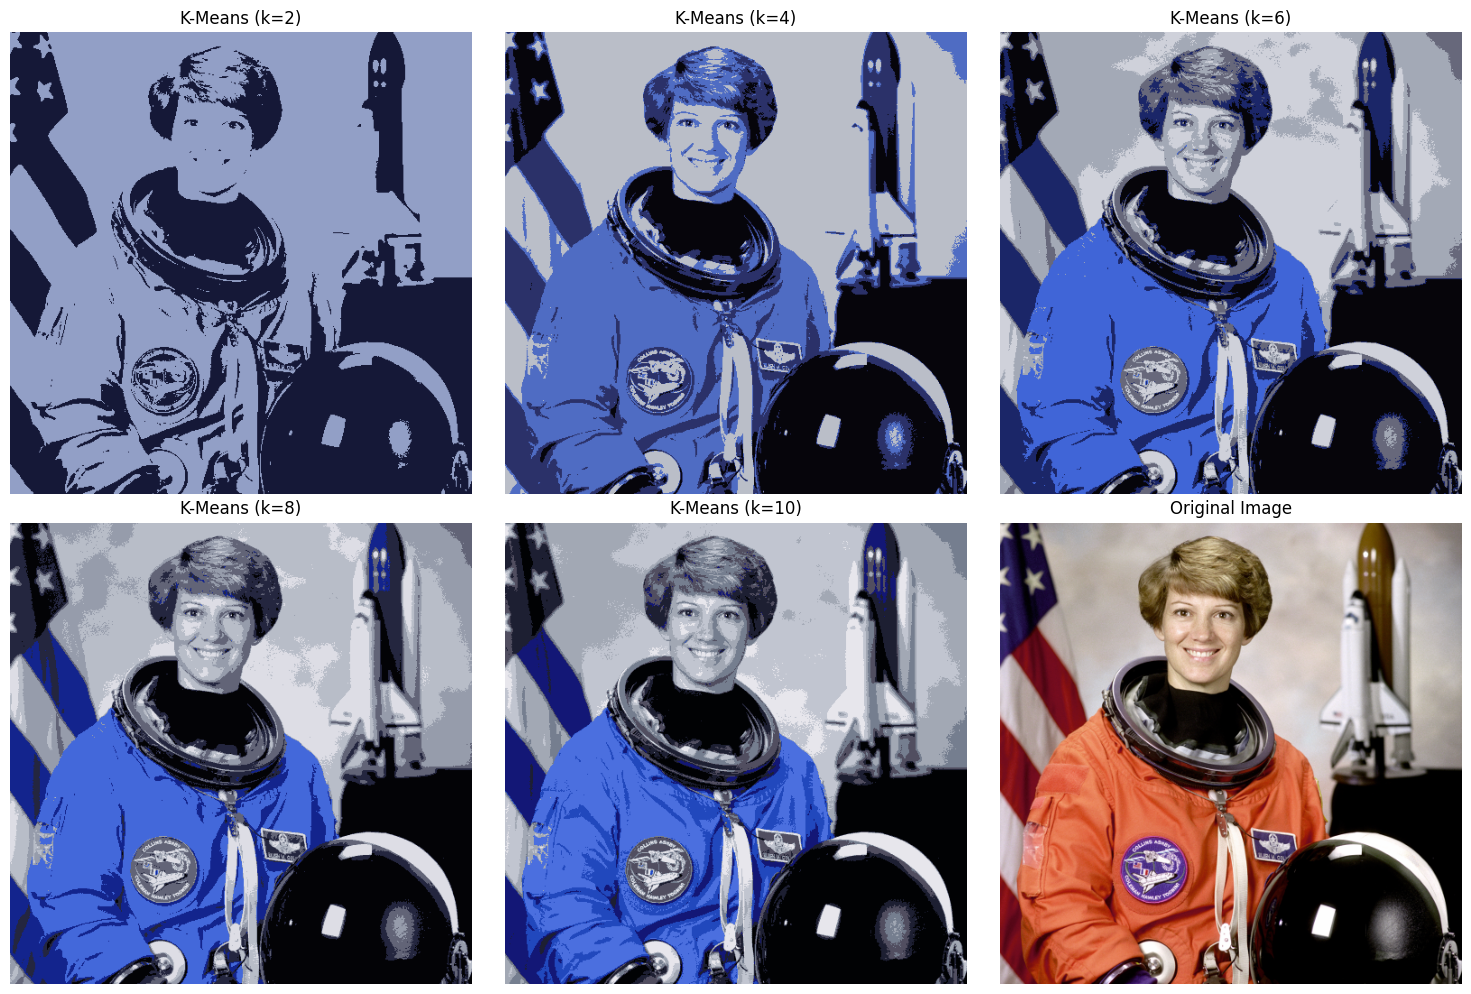

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.data import astronaut  # Importing sample image from skimage

# Load sample image (astronaut) from skimage
image = astronaut()

# Convert image from RGB to BGR (OpenCV default format) for k-means processing
image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

# Reshape image into a 2D array (Each row = [R, G, B] pixel values)
pixel_vals = image_bgr.reshape((-1, 3))

# Convert pixel values to float32 for k-means clustering
pixel_vals = np.float32(pixel_vals)

# Define stopping criteria for k-means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)

# Define different values of k for segmentation
k_values = [2, 4, 6, 8, 10]  # Number of clusters

# Set up the figure
plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values, 1):
    # Apply k-means clustering
    retval, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Convert cluster centers back to 8-bit (0-255) integers
    centers = np.uint8(centers)

    # Map labels to their respective cluster centers
    segmented_data = centers[labels.flatten()]

    # Reshape the segmented data to match the original image dimensions
    segmented_image = segmented_data.reshape(image.shape)

    # Plot the segmented image
    plt.subplot(2, 3, i)
    plt.imshow(segmented_image)
    plt.title(f"K-Means (k={k})")
    plt.axis("off")

# Plot the original image in the last subplot
plt.subplot(2, 3, len(k_values) + 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Adjust layout and show plots
plt.tight_layout()
plt.show()
